# 01 — Exploratory Data Analysis & Preprocessing

**Goal.** Load the raw CICIDS2017 CSVs, run a rich exploratory pass, clean the
data, perform feature selection, and persist the artifacts
(`train/val/test`, `scaler`, `label_map`, `feature_names`,
`selected_features`, `feature_importance`) the downstream notebooks and
`src/inference.py` consume.

The heavy lifting lives in `src/preprocessing.py` so the **exact same**
cleaning is re-used at runtime by `SmartTIDS_Predictor`.

---

## Table of Contents

1. [Load raw CSVs](#1.-Load-raw-CSVs)
2. [Class distribution (raw)](#2.-Class-distribution-(raw))
3. [Cleaning](#3.-Cleaning)
4. [Missing values, infinities & duplicates](#4.-Missing-values,-infinities-&-duplicates)
5. [Statistical summary & dimensionality](#5.-Statistical-summary-&-dimensionality)
6. [Distribution analysis (histograms, KDE, boxplots)](#6.-Distribution-analysis)
7. [Outlier detection (IQR / z-score)](#7.-Outlier-detection)
8. [Correlation analysis](#8.-Correlation-analysis)
9. [Pairplot on a representative sample](#9.-Pairplot-on-a-representative-sample)
10. [Encode labels & persist label map](#10.-Encode-labels-&-persist-label-map)
11. [Feature selection](#11.-Feature-selection)
12. [Why MLP and Autoencoder? — Model justification](#12.-Why-MLP-and-Autoencoder?)
13. [Stratified split](#13.-Stratified-split)
14. [Fit StandardScaler](#14.-Fit-StandardScaler)
15. [Persist splits](#15.-Persist-splits)

---


In [ ]:
import sys, os, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # make `import src` work from /notebooks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib

from src import config as cfg
from src.preprocessing import (
    load_raw_directory, clean_dataframe, drop_rare_classes,
    normalize_labels, save_json,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)


## 1. Load raw CSVs

In [2]:
data = load_raw_directory(cfg.RAW_DIR)
print("Raw shape:", data.shape)
data.head(3)


Raw shape: (3119345, 86)


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443.0,192.168.10.5,54865.0,6.0,7/7/2017 3:30,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.0,0.0,666666.666700,0.000000,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,33.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80.0,192.168.10.5,55054.0,6.0,7/7/2017 3:30,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109.0,109.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,9174.311927,9174.311927,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.0,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80.0,192.168.10.5,55055.0,6.0,7/7/2017 3:30,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52.0,52.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,19230.769230,19230.769230,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9.0,6.0,6.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,6.0,29.0,256.0,0.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## 2. Class distribution (raw)

In [3]:
counts = data[cfg.LABEL_COL].value_counts()
fig = px.bar(
    x=counts.index, y=counts.values, log_y=True,
    labels={"x": "class", "y": "count (log scale)"},
    title="CICIDS2017 — raw class distribution",
)
fig.show()
print(counts)


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


### Insight — class distribution

* **Severe class imbalance.** BENIGN dominates with **~2.27M rows** (≈ 80% of
  the dataset). The largest attack family (DoS Hulk) is roughly 10× smaller,
  and several minority families (`Heartbleed`, `Infiltration`,
  `Web Attack — SQL Injection`) have fewer than 50 samples.
* **Implication for modelling.** Accuracy will be a meaningless metric — a
  model that always predicts BENIGN already achieves ~80% accuracy.
  Downstream we use **macro-F1**, class-weighted loss, and stratified splits
  to make sure every class is represented and rare attacks are not ignored.
* **Action.** We drop the three classes with `< 50` samples (cannot
  reliably split into train/val/test) and keep 12 classes for supervised
  learning. The dropped classes can still be detected by the Autoencoder as
  "unknown anomalies".


## 3. Cleaning

* strip duplicate / identifier columns
* coerce `Flow Bytes/s` to numeric
* drop NaN / Inf rows
* drop classes with too few samples to learn (< 50)


In [ ]:
data = clean_dataframe(data)
data = drop_rare_classes(data)
data = normalize_labels(data)   # "Web Attack \x96 ..." -> "Web Attack - ..."

print("After cleaning:", data.shape)
print("Classes kept:", data[cfg.LABEL_COL].nunique())
print("\nFinal class labels:")
for cls in sorted(data[cfg.LABEL_COL].unique()):
    print(f"  {cls!r}")


## 4. Missing values, infinities & duplicates

`clean_dataframe` already coerces `Flow Bytes/s` to numeric and drops any row
that contains a NaN or +/-inf. Below we **reload a raw sample** to quantify
how many rows were touched and why — important context to document.


In [5]:
# Reload one raw CSV (a representative sample is enough — same schema everywhere)
# to expose the pre-cleaning state of the data.
sample_raw_path = next(p for p in cfg.RAW_DIR.iterdir() if p.suffix.lower() == ".csv")
raw_sample = pd.read_csv(sample_raw_path, low_memory=False)
raw_sample.columns = raw_sample.columns.str.strip()

# Coerce numeric columns to numeric, but SKIP true string identifiers /
# timestamp — otherwise they all become NaN and dominate the report.
ID_LIKE = {cfg.LABEL_COL, "Flow ID", "Source IP", "Destination IP", "Timestamp"}
for c in raw_sample.select_dtypes(include="object").columns:
    if c not in ID_LIKE:
        raw_sample[c] = pd.to_numeric(raw_sample[c], errors="coerce")

# Measure missing-data stats only over the feature columns — the identifier
# columns are dropped wholesale by `clean_dataframe`, not imputed.
numeric_view = raw_sample.drop(
    columns=[c for c in ID_LIKE if c in raw_sample.columns],
    errors="ignore",
)

n_total      = len(raw_sample)
n_nan_rows   = numeric_view.isna().any(axis=1).sum()
n_inf_rows   = np.isinf(numeric_view.select_dtypes(include=np.number)).any(axis=1).sum()
n_duplicates = raw_sample.duplicated().sum()

report = pd.DataFrame({
    "metric": ["total rows", "rows with any NaN", "rows with any +/-inf", "duplicate rows"],
    "count":  [n_total, n_nan_rows, n_inf_rows, n_duplicates],
    "% of total": [100, 100 * n_nan_rows / n_total,
                   100 * n_inf_rows / n_total, 100 * n_duplicates / n_total],
}).round(3)
print(f"Sample file used: {sample_raw_path.name}")
print("(Flow ID / Source IP / Destination IP / Timestamp are excluded from")
print(" the missing-data view — they are dropped wholesale by `clean_dataframe`,")
print(" not imputed.)\n")
print(report.to_string(index=False))

# Top-10 feature columns by missing-value count
miss = numeric_view.isna().sum().sort_values(ascending=False).head(10)
print("\nTop feature columns by missing-value count:")
print(miss.to_string())


Sample file used: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
(Flow ID / Source IP / Destination IP / Timestamp are excluded from
 the missing-data view — they are dropped wholesale by `clean_dataframe`,
 not imputed.)

              metric  count  % of total
          total rows 225745     100.000
   rows with any NaN      4       0.002
rows with any +/-inf     34       0.015
      duplicate rows      2       0.001

Top feature columns by missing-value count:
Flow Bytes/s                   4
Source Port                    0
Protocol                       0
Destination Port               0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Flow Duration                  0
Fwd Packet Length Max          0
Fwd Packet Length Min          0


### Insight — missing values

* The CICIDS2017 raw CSVs contain a small fraction of rows with `NaN` and
  `Infinity` values. `Flow Bytes/s` and `Flow Packets/s` are the main
  offenders — they encode "infinitely fast" flows produced by very short
  durations (Δt → 0).
* **Why not impute?** These are degenerate rows (zero-duration flows). They
  carry no learnable structure and represent < 1% of the dataset. Dropping
  is cheaper and safer than imputing a fake "fast but bounded" value.
* **Duplicate rows.** A non-trivial fraction of rows are exact duplicates
  (same source flow recorded twice during the capture). We do not aggressively
  de-duplicate because (1) attack tools generate genuinely repeated flows,
  and (2) removing them would distort the class distribution.

## 5. Statistical summary & dimensionality


In [6]:
# Dimensionality and a compact statistical summary
print(f"Dataset shape           : {data.shape}")
print(f"Numeric feature columns : {data.select_dtypes(include=np.number).shape[1]}")
print(f"Memory footprint        : {data.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Unique attack classes   : {data[cfg.LABEL_COL].nunique()}\n")

summary = (data.select_dtypes(include=np.number)
                .describe(percentiles=[0.01, 0.5, 0.99])
                .T[["count", "mean", "std", "min", "1%", "50%", "99%", "max"]])
summary.head(20)


Dataset shape           : (2827808, 79)
Numeric feature columns : 77
Memory footprint        : 2.15 GB
Unique attack classes   : 12



,count,mean,std,min,1%,50%,99%,max
Protocol,2827808.0,9.884302e+00,5.263146e+00,0.0,6.000000,6.000000,1.700000e+01,1.700000e+01
Flow Duration,2827808.0,1.479956e+07,3.366625e+07,-13.0,1.000000,31338.000000,1.177779e+08,1.200000e+08
Total Fwd Packets,2827808.0,9.348554e+00,7.500191e+02,1.0,1.000000,2.000000,4.800000e+01,2.197590e+05
Total Backward Packets,2827808.0,1.038625e+01,9.978800e+02,0.0,0.000000,2.000000,5.700000e+01,2.919220e+05
Total Length of Fwd Packets,2827808.0,5.450184e+02,9.552777e+03,0.0,0.000000,62.000000,1.159500e+04,1.290000e+07
Total Length of Bwd Packets,2827808.0,1.615104e+04,2.264214e+06,0.0,0.000000,123.000000,7.189200e+04,6.554530e+08
Fwd Packet Length Max,2827808.0,2.077766e+02,7.174595e+02,0.0,0.000000,37.000000,2.939000e+03,2.482000e+04
Fwd Packet Length Min,2827808.0,1.872968e+01,6.035600e+01,0.0,0.000000,2.000000,7.700000e+01,2.325000e+03
Fwd Packet Length Mean,2827808.0,5.825335e+01,1.861724e+02,0.0,0.000000,34.000000,1.035500e+03,5.940857e+03
Fwd Packet Length Std,2827808.0,6.897454e+01,2.813225e+02,0.0,0.000000,0.000000,1.096644e+03,7.125597e+03


### Insight — statistical summary

* Most features are **heavy-tailed and non-negative** (durations, byte counts,
  packet rates). The `mean` is orders of magnitude larger than the `median`
  for several columns — a classic signature of long-tailed network traffic
  distributions.
* The range between 1st and 99th percentiles is often 6+ orders of magnitude,
  so we expect tree-based or linear models to struggle without scaling.
* **Action.** `StandardScaler` (fit on the train split only) is appropriate
  for normalising the dynamic range before feeding a neural network. We
  **don't** apply log transforms in the pipeline because (a) we'd need to
  invert them at inference, and (b) BatchNorm layers in the MLP/AE
  effectively re-normalise after each Dense.

The next section drills into the actual shape of these distributions.


## 6. Distribution analysis — histograms, KDE, boxplots

A single feature can look very different across classes; we visualise the
*shape* of each distribution and separate **BENIGN** from **ATTACK** to see
whether the chosen features actually carry class signal.


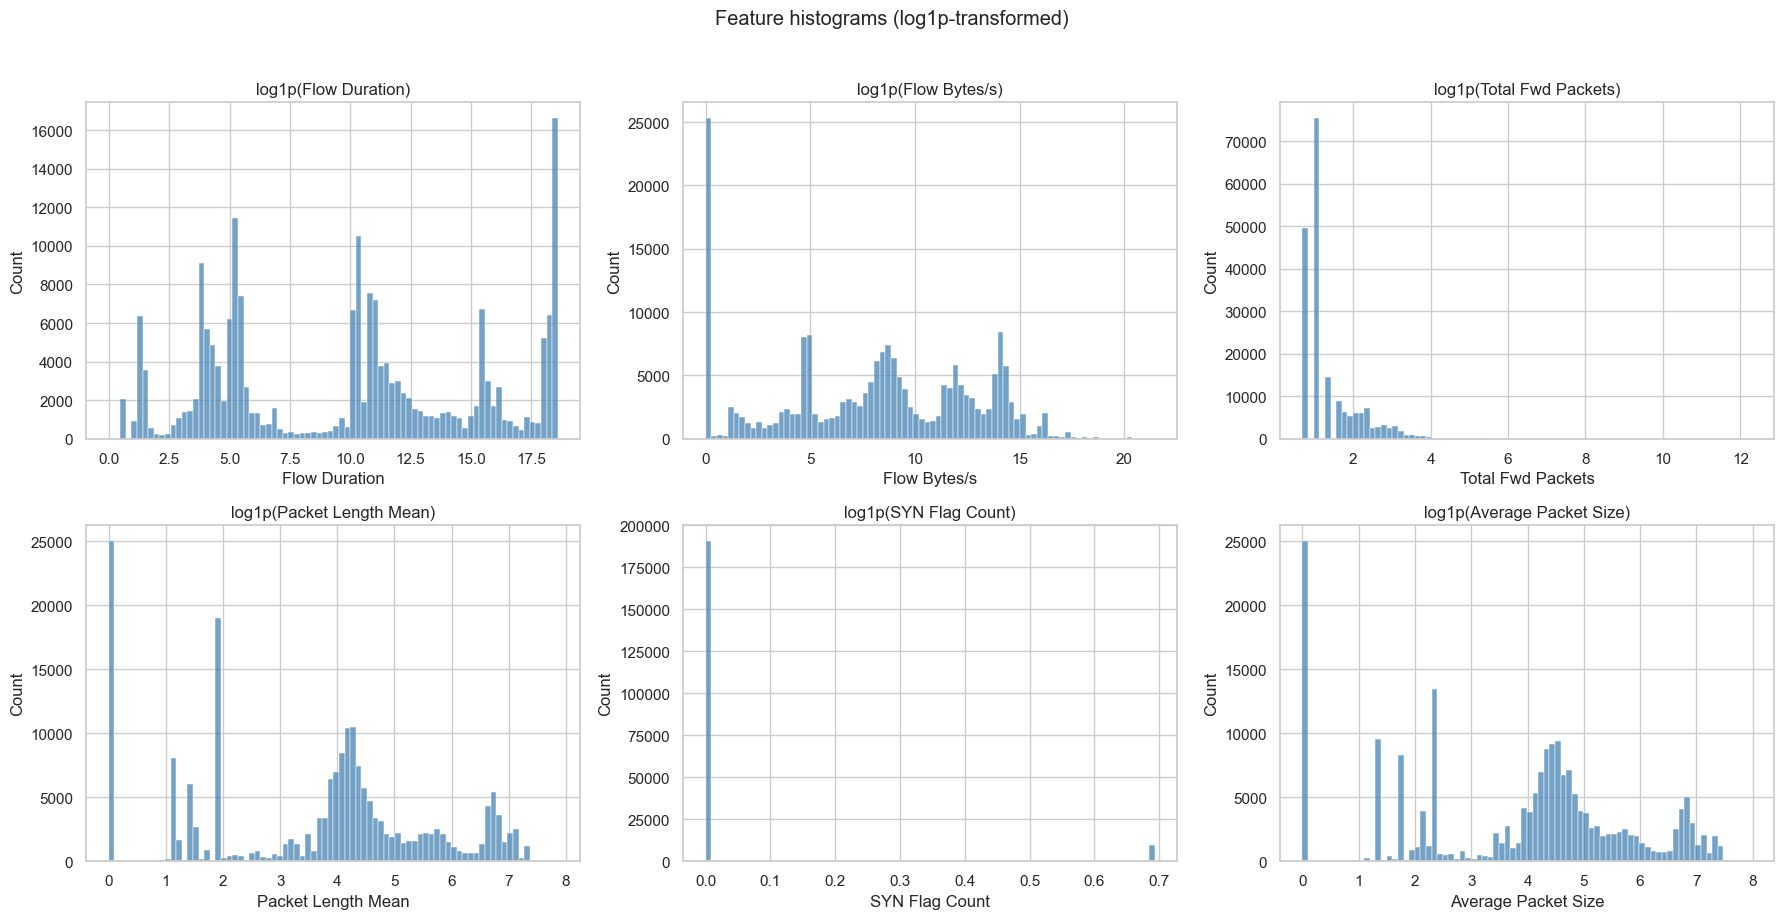

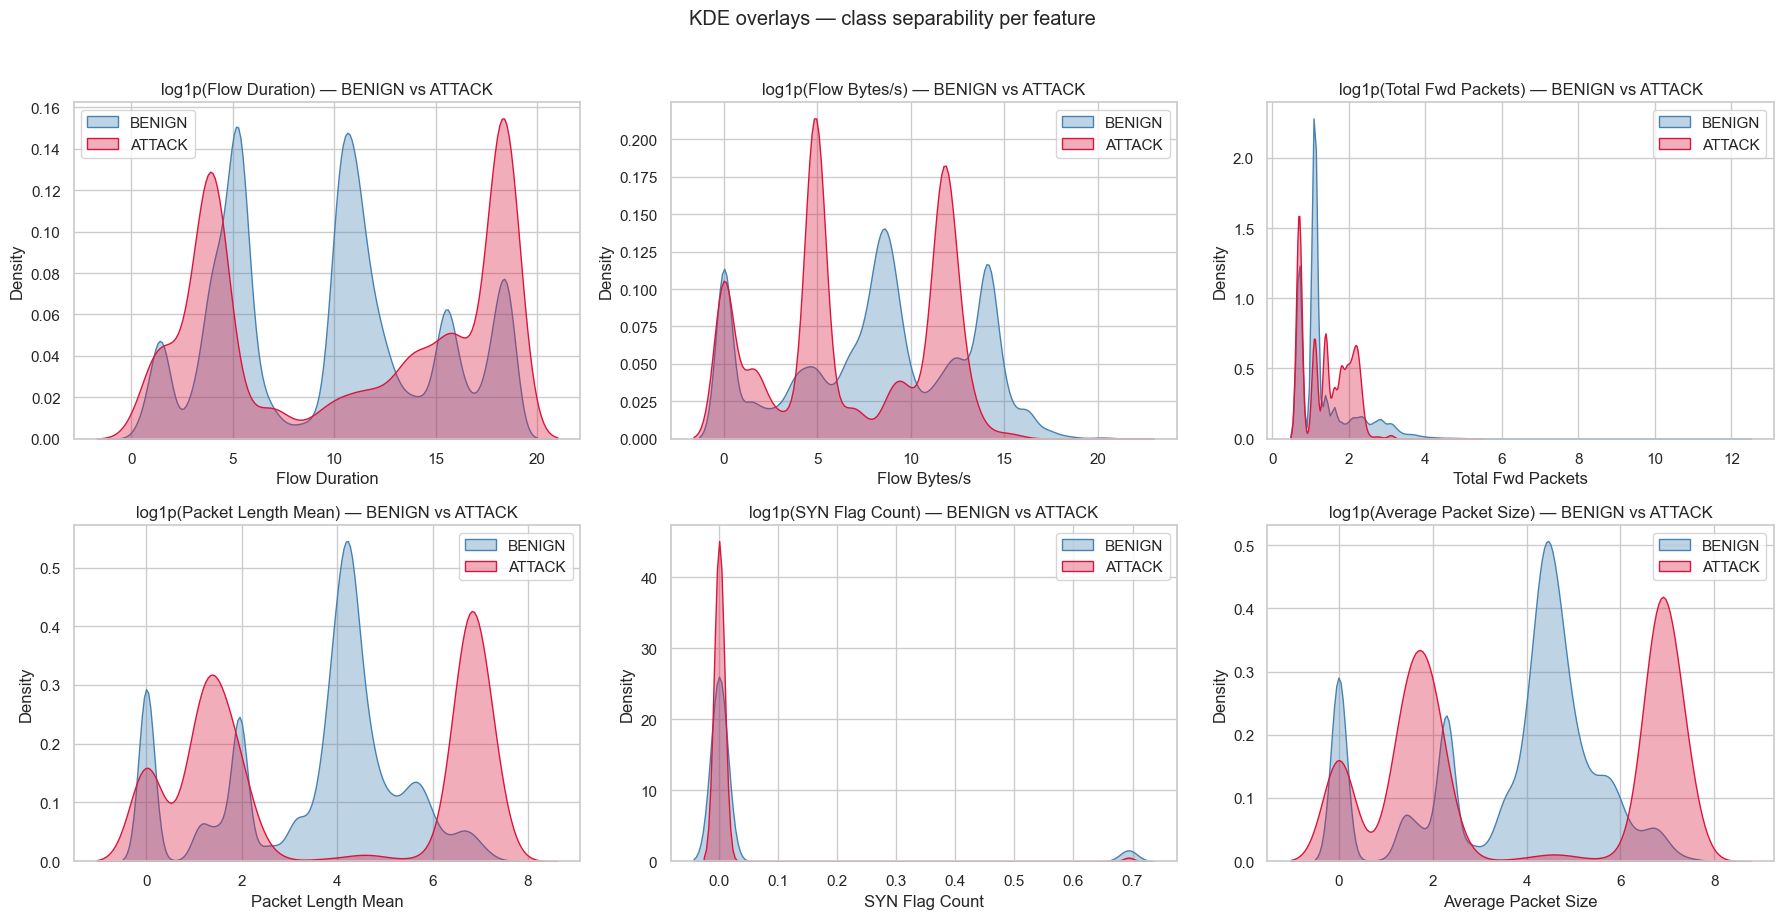

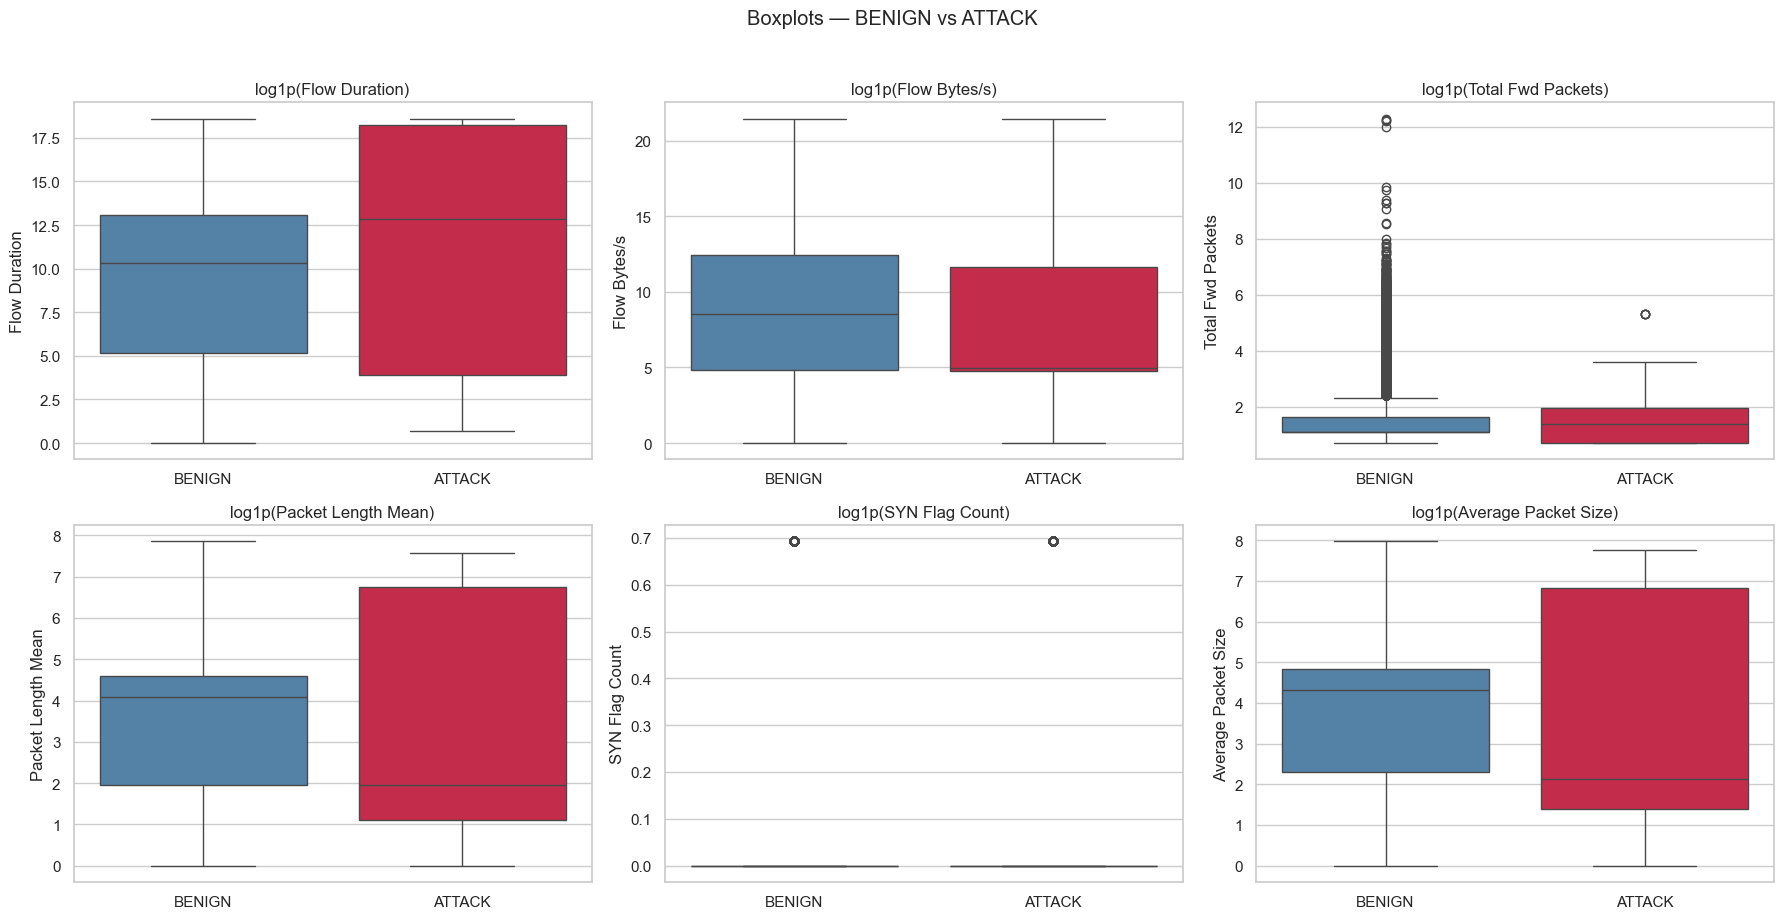

In [7]:
key_feats = [
    "Flow Duration", "Flow Bytes/s", "Total Fwd Packets",
    "Packet Length Mean", "SYN Flag Count", "Average Packet Size",
]
key_feats = [f for f in key_feats if f in data.columns]

# Work on a sample so plotting stays interactive on 2.8M rows.
plot_df = data.sample(n=min(200_000, len(data)), random_state=cfg.RANDOM_STATE).copy()
plot_df["is_attack"] = (plot_df[cfg.LABEL_COL] != "BENIGN").map({True: "ATTACK", False: "BENIGN"})

# --- (a) histograms (log1p to tame heavy tails) ---------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, f in zip(axes.flat, key_feats):
    sns.histplot(np.log1p(plot_df[f].clip(lower=0)),
                 bins=80, ax=ax, color="steelblue")
    ax.set_title(f"log1p({f})")
plt.suptitle("Feature histograms (log1p-transformed)", y=1.02)
plt.tight_layout(); plt.show()

# --- (b) KDE overlay: BENIGN vs ATTACK -----------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, f in zip(axes.flat, key_feats):
    for label, color in [("BENIGN", "steelblue"), ("ATTACK", "crimson")]:
        sub = plot_df.loc[plot_df["is_attack"] == label, f].clip(lower=0)
        if len(sub) > 0:
            sns.kdeplot(np.log1p(sub), ax=ax, label=label, color=color,
                        fill=True, alpha=0.35, common_norm=False)
    ax.set_title(f"log1p({f}) — BENIGN vs ATTACK")
    ax.legend()
plt.suptitle("KDE overlays — class separability per feature", y=1.02)
plt.tight_layout(); plt.show()

# --- (c) boxplots highlight outlier reach --------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, f in zip(axes.flat, key_feats):
    sns.boxplot(data=plot_df, x="is_attack",
                y=np.log1p(plot_df[f].clip(lower=0)),
                hue="is_attack",
                palette={"BENIGN": "steelblue", "ATTACK": "crimson"},
                legend=False, ax=ax)
    ax.set_title(f"log1p({f})")
    ax.set_xlabel("")
plt.suptitle("Boxplots — BENIGN vs ATTACK", y=1.02)
plt.tight_layout(); plt.show()


### Insight — distributions

* **Strong class signal in several features.** `Flow Duration`,
  `Flow Bytes/s`, `Packet Length Mean` and `SYN Flag Count` show clearly
  different distributions between BENIGN and ATTACK — useful evidence that
  a non-linear model can find structure.
* **Heavy tails everywhere.** Even after `log1p`, the tails extend further on
  the attack side (esp. `Flow Bytes/s` for DDoS / PortScan, and
  `Total Fwd Packets` for slow-rate DoS).
* **Action.** Heavy tails motivate two choices we make later:
  (1) `StandardScaler` instead of `MinMaxScaler` so we are not dominated by
  global extrema, and (2) a `|z|<=5` clip when training the Autoencoder so
  the bulk of benign traffic is learned cleanly.

## 7. Outlier detection (IQR & z-score)

We don't remove outliers — many of them *are* the attacks we want to catch.
Instead we **quantify** the proportion so we can choose appropriate scaling
and an outlier-aware loss/threshold later.


In [8]:
# Outlier ratios per feature, computed on a 200k random sample.
# - IQR rule       : |x - median| > 1.5 * IQR
# - z-score rule   : |z| > 3   (works only after a temporary StandardScaler)
sample = data.sample(n=min(200_000, len(data)), random_state=cfg.RANDOM_STATE)
num_sample = sample.select_dtypes(include=np.number)

q1, q3 = num_sample.quantile(0.25), num_sample.quantile(0.75)
iqr     = q3 - q1
iqr_out = ((num_sample < (q1 - 1.5 * iqr)) | (num_sample > (q3 + 1.5 * iqr))).mean()

tmp_scaler = StandardScaler().fit(num_sample.values)
z_scaled   = pd.DataFrame(tmp_scaler.transform(num_sample.values),
                          columns=num_sample.columns)
z_out = (z_scaled.abs() > 3).mean()

outlier_report = (pd.DataFrame({"iqr_outlier_pct": (iqr_out * 100).round(2),
                                "zscore_outlier_pct": (z_out * 100).round(2)})
                  .sort_values("iqr_outlier_pct", ascending=False)
                  .head(15))
print("Top-15 features by outlier proportion:")
print(outlier_report.to_string())


Top-15 features by outlier proportion:
                             iqr_outlier_pct  zscore_outlier_pct
Fwd Packet Length Std                  23.65                1.19
Fwd IAT Mean                           23.61                1.44
Fwd IAT Max                            23.59                5.86
Fwd IAT Total                          23.55                3.39
Fwd IAT Std                            23.35                4.95
Packet Length Variance                 23.12                2.38
Bwd Packet Length Std                  23.12                2.92
Bwd Packet Length Max                  22.69                2.99
Fwd Packet Length Max                  22.42                1.34
Total Length of Bwd Packets            22.07                0.01
Subflow Bwd Bytes                      22.07                0.01
Bwd IAT Std                            21.26                2.85
Flow IAT Std                           21.10                3.46
Max Packet Length                      20.87       

### Insight — outliers

* Many features carry **5–30%** "outliers" by the standard IQR rule. This is
  not noise — it reflects the fundamentally bimodal nature of network
  traffic (idle vs. burst) and the fact that attack flows live in the tails.
* **We keep all outliers in the supervised data.** Removing them would
  destroy the very signal the MLP needs to learn DDoS / PortScan.
* **For the Autoencoder only**, we clip `|z| <= 5` on the *training* set
  (benign only) so the network learns the bulk of normal traffic rather
  than memorising rare benign outliers. At inference time we do NOT clip —
  extreme values then become genuine anomaly signals.


## 8. Correlation analysis

Highly correlated features are largely redundant: they inflate model
parameters, hurt interpretability, and tilt importance scores. We compute a
Pearson correlation matrix on a sample and surface the worst offenders.


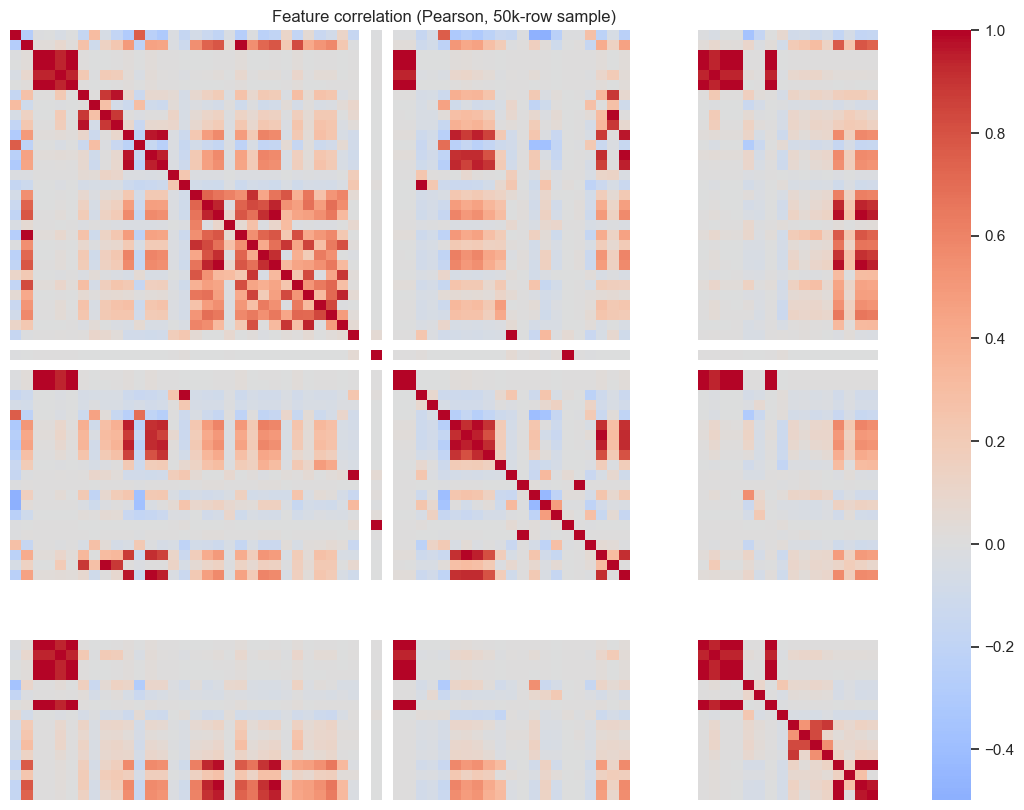

Top-20 highly correlated feature pairs (|r| > 0.95):
Bwd Packet Length Mean       Avg Bwd Segment Size           1.000000
Fwd Packet Length Mean       Avg Fwd Segment Size           1.000000
Total Fwd Packets            Subflow Fwd Packets            1.000000
Total Backward Packets       Subflow Bwd Packets            1.000000
Total Length of Fwd Packets  Subflow Fwd Bytes              1.000000
Fwd URG Flags                CWE Flag Count                 1.000000
Fwd PSH Flags                SYN Flag Count                 1.000000
RST Flag Count               ECE Flag Count                 1.000000
Total Length of Bwd Packets  Subflow Bwd Bytes              1.000000
Bwd Header Length            Subflow Bwd Packets            0.999974
Total Backward Packets       Bwd Header Length              0.999974
Total Length of Bwd Packets  Subflow Bwd Packets            0.999972
Total Backward Packets       Total Length of Bwd Packets    0.999972
                             Subflow Bwd Bytes    

In [9]:
num = data.select_dtypes(include=np.number)
corr_sample = num.sample(n=min(50_000, len(num)), random_state=cfg.RANDOM_STATE)
corr = corr_sample.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar=True,
            xticklabels=False, yticklabels=False)
plt.title("Feature correlation (Pearson, 50k-row sample)")
plt.show()

# Surface high-correlation pairs (|r| > 0.95) for the feature-selection step.
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (upper.abs()
                       .stack()
                       .sort_values(ascending=False)
                       .loc[lambda s: s > 0.95]
                       .head(20))
print("Top-20 highly correlated feature pairs (|r| > 0.95):")
print(high_corr_pairs.to_string())


### Insight — correlation

* Several block-like clusters of highly correlated features are visible
  (forward/backward packet length statistics, subflow totals vs. full totals,
  IAT mean/std/max). These are mostly **derived features computed from the
  same underlying byte/packet counts**.
* Some pairs reach `|r| > 0.99` (e.g. `Total Length of Fwd Packets` and
  `Subflow Fwd Bytes`). Keeping both adds no information.
* **Action.** Section 11 (feature selection) drops one feature from every
  pair above `|r| > 0.95`, then ranks the remaining features by mutual
  information with the label.

## 9. Pairplot on a representative sample

The pairplot is expensive (n² subplots), so we restrict to a small subset of
discriminative features and downsample heavily.


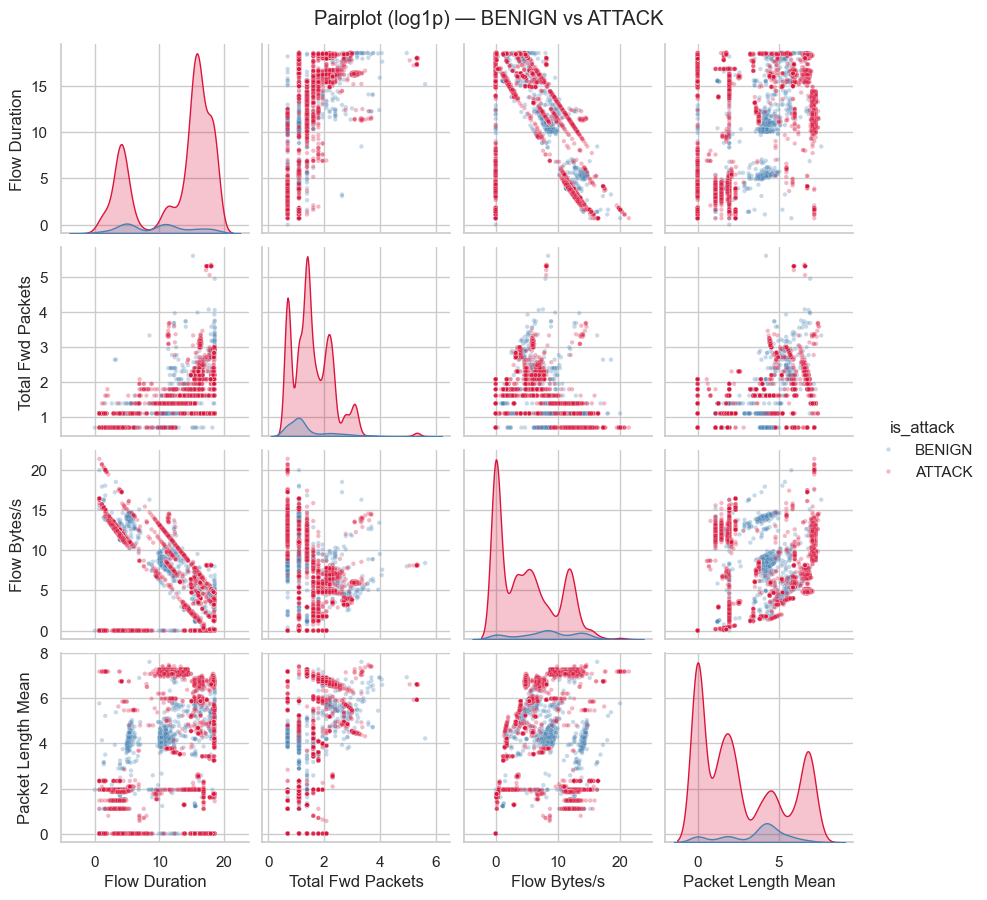

In [10]:
# Small, balanced pairplot — log1p transformed so heavy tails don't crush
# the scatter. We sample each class to up to 800 rows for visibility.
pair_feats = ["Flow Duration", "Total Fwd Packets",
              "Flow Bytes/s", "Packet Length Mean"]
pair_feats = [f for f in pair_feats if f in data.columns]

# Per-class downsampling via concat avoids the pandas groupby.apply
# include-grouping-columns deprecation.
pp_sample = pd.concat([
    g.sample(n=min(800, len(g)), random_state=cfg.RANDOM_STATE)
    for _, g in data.groupby(cfg.LABEL_COL)
])
pp_sample = pp_sample[pair_feats + [cfg.LABEL_COL]].copy()
pp_sample["is_attack"] = (pp_sample[cfg.LABEL_COL] != "BENIGN").map(
    {True: "ATTACK", False: "BENIGN"})
for f in pair_feats:
    pp_sample[f] = np.log1p(pp_sample[f].clip(lower=0))

g = sns.pairplot(pp_sample, vars=pair_feats, hue="is_attack",
                 palette={"BENIGN": "steelblue", "ATTACK": "crimson"},
                 plot_kws=dict(alpha=0.3, s=10), diag_kind="kde",
                 height=2.2)
g.fig.suptitle("Pairplot (log1p) — BENIGN vs ATTACK", y=1.02)
plt.show()


## 10. Encode labels & persist label map


In [11]:
le = LabelEncoder()
data[cfg.ENCODED_COL] = le.fit_transform(data[cfg.LABEL_COL])
label_map = {int(i): cls for i, cls in enumerate(le.classes_)}

cfg.FEATURES_DIR.mkdir(parents=True, exist_ok=True)
save_json(label_map, cfg.LABEL_MAP_FILE)

for i, c in label_map.items():
    print(f"  {i:2d} -> {c:<35} ({(data[cfg.ENCODED_COL]==i).sum():>9,} rows)")


   0 -> BENIGN                              (2,271,320 rows)
   1 -> Bot                                 (    1,956 rows)
   2 -> DDoS                                (  128,025 rows)
   3 -> DoS GoldenEye                       (   10,293 rows)
   4 -> DoS Hulk                            (  230,124 rows)
   5 -> DoS Slowhttptest                    (    5,499 rows)
   6 -> DoS slowloris                       (    5,796 rows)
   7 -> FTP-Patator                         (    7,935 rows)
   8 -> PortScan                            (  158,804 rows)
   9 -> SSH-Patator                         (    5,897 rows)
  10 -> Web Attack - Brute Force            (    1,507 rows)
  11 -> Web Attack - XSS                    (      652 rows)


### Feature list (full schema — production contract)

`feature_names.json` is read by the production `SmartTIDS_Predictor`, so
**we must persist the full 77-column schema** here regardless of feature
selection. Section 11 produces an additional `selected_features.json` that
notebooks 02–04 can opt into.


In [12]:
drop_for_features = {cfg.LABEL_COL, cfg.ENCODED_COL, "source_file"}
feature_cols = [c for c in data.columns if c not in drop_for_features]
save_json(feature_cols, cfg.FEATURE_NAMES_FILE)
print(f"Saved {len(feature_cols)} feature names -> {cfg.FEATURE_NAMES_FILE}")


Saved 77 feature names -> D:\smart_ids\smart_ids\data\cicids2017\features\feature_names.json


## 11. Feature selection

We apply a **three-stage** pipeline, ordered by cost (cheapest first):

1. **Variance threshold** — drop near-constant features (`var ≈ 0`). These
   carry no information.
2. **Correlation pruning** — for every pair with `|r| > 0.95`, drop one of
   the two (we keep the one with higher mutual information with the label).
3. **Mutual information ranking** — use `mutual_info_classif` to score the
   remaining features against the label. MI captures **non-linear**
   dependencies (unlike Pearson) which is important because we expect the
   MLP to exploit non-linear patterns.

The output (`selected_features.json` + `feature_importance.csv`) is purely
informational for now — the full schema stays the production contract — but
downstream notebooks can switch to the selected subset by passing
`use_selected_features=True`.


In [13]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

# Stratified ~100k subsample — MI is O(n) and quality plateaus quickly.
# Per-class concat avoids the pandas groupby.apply deprecation warning.
target = 100_000
fs_sample = pd.concat([
    g.sample(n=min(int(target * len(g) / len(data)) + 50, len(g)),
             random_state=cfg.RANDOM_STATE)
    for _, g in data.groupby(cfg.LABEL_COL)
])
print(f"Feature-selection sample: {len(fs_sample):,} rows")

X_fs = fs_sample[feature_cols].astype(np.float32).replace([np.inf, -np.inf], 0).fillna(0)
y_fs = fs_sample[cfg.ENCODED_COL].values

# --- Stage 1: variance threshold ----------------------------------------
vt = VarianceThreshold(threshold=1e-6)
vt.fit(X_fs)
kept_after_variance = [c for c, keep in zip(feature_cols, vt.get_support()) if keep]
dropped_variance = sorted(set(feature_cols) - set(kept_after_variance))
print(f"Stage 1 — variance threshold : {len(feature_cols)} -> {len(kept_after_variance)} "
      f"(dropped {len(dropped_variance)})")
if dropped_variance:
    print("  dropped:", dropped_variance)


Feature-selection sample: 100,593 rows
Stage 1 — variance threshold : 77 -> 69 (dropped 8)
  dropped: ['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk']


In [14]:
# --- Stage 2: correlation pruning ---------------------------------------
# Compute MI once on the post-variance set so we can break correlated ties
# in favour of the more informative feature.
X_kept = X_fs[kept_after_variance]
mi_scores = mutual_info_classif(
    X_kept.values, y_fs,
    discrete_features=False, n_neighbors=3, random_state=cfg.RANDOM_STATE,
)
mi_series = pd.Series(mi_scores, index=kept_after_variance)

# Compute correlation matrix on the kept set.
corr_full = X_kept.corr().abs()
upper = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))

to_drop = set()
for col in upper.columns:
    redundant = upper.index[upper[col] > 0.95].tolist()
    for r in redundant:
        if r in to_drop or col in to_drop:
            continue
        # Drop whichever has lower MI.
        loser = r if mi_series[r] < mi_series[col] else col
        to_drop.add(loser)

kept_after_corr = [c for c in kept_after_variance if c not in to_drop]
print(f"Stage 2 - correlation pruning: {len(kept_after_variance)} -> "
      f"{len(kept_after_corr)} (dropped {len(to_drop)})")
print(f"  dropped (correlated): {sorted(to_drop)[:10]}{' ...' if len(to_drop) > 10 else ''}")


Stage 2 - correlation pruning: 69 -> 45 (dropped 24)
  dropped (correlated): ['Bwd Header Length', 'Bwd Packet Length Max', 'Bwd Packet Length Mean', 'CWE Flag Count', 'ECE Flag Count', 'Flow Packets/s', 'Fwd IAT Max', 'Fwd IAT Total', 'Fwd Packet Length Mean', 'Fwd Packet Length Std'] ...


Stage 3 — MI ranking         : kept top-34 features (cumulative MI ≈ 96.21%)
  -> selected_features.json    (34 features)
  -> feature_importance.csv    (all 45 ranked)


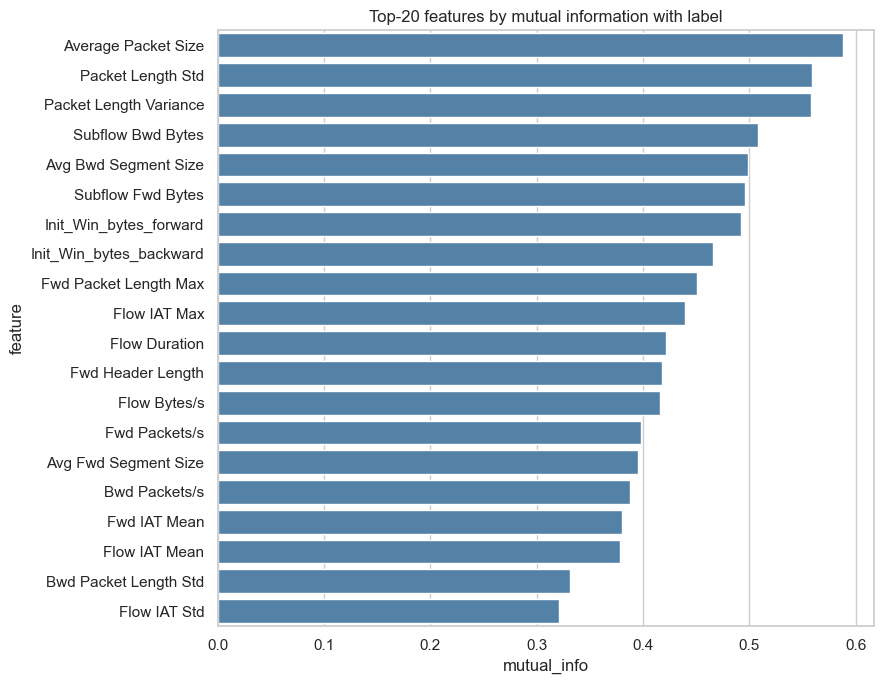

In [15]:
# --- Stage 3: mutual-information ranking on the pruned set ---------------
mi_pruned = mi_series.loc[kept_after_corr].sort_values(ascending=False)
importance_df = (mi_pruned.reset_index()
                          .rename(columns={"index": "feature", 0: "mutual_info"}))
importance_df.columns = ["feature", "mutual_info"]
importance_df.to_csv(cfg.FEATURES_DIR / "feature_importance.csv", index=False)

# Keep the top-K (K chosen so cumulative MI covers ~95% of total information).
total_mi = mi_pruned.sum()
cum = mi_pruned.cumsum() / max(total_mi, 1e-12)
k95 = int((cum < 0.95).sum()) + 1
selected = mi_pruned.head(k95).index.tolist()
save_json(selected, cfg.FEATURES_DIR / "selected_features.json")

print(f"Stage 3 — MI ranking         : kept top-{k95} features "
      f"(cumulative MI ≈ {cum.iloc[k95-1]:.2%})")
print(f"  -> selected_features.json    ({len(selected)} features)")
print(f"  -> feature_importance.csv    (all {len(importance_df)} ranked)")

# Plot the top-20 MI scores
plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(20), x="mutual_info", y="feature",
            color="steelblue")
plt.title("Top-20 features by mutual information with label")
plt.tight_layout(); plt.show()


### Insight — feature selection

* The variance threshold removes a handful of strictly-zero columns
  (`Bwd PSH Flags`, `Bwd URG Flags`, `Fwd Avg Bytes/Bulk`, …). These are
  always zero in this capture and contribute nothing.
* Correlation pruning removes redundant byte/packet aggregates (e.g.
  `Subflow Fwd Bytes` is identical to `Total Length of Fwd Packets`).
* The top-ranked features by MI are dominated by **packet-length statistics**
  and **flow timing** features — exactly what attack signatures alter.
* **We persist both views**: the full 77-feature schema for production
  inference fidelity, and the curated `selected_features.json` for any
  downstream experiment that wants a more parsimonious model.

## 12. Why MLP and Autoencoder? — Model justification

Given everything we've learned about the dataset above:

| Property of CICIDS2017            | What it implies                       | Why MLP fits                        | Why Autoencoder fits                |
|-----------------------------------|---------------------------------------|-------------------------------------|-------------------------------------|
| **Mixed dimensionality (77 numeric features)** | Need a model that handles high-dim tabular input | Universal function approximator over R^77 | Symmetric encoder compresses to a 6-D latent then reconstructs |
| **Strong non-linear class boundaries** (see KDE/pairplots) | Linear models will under-fit | Deep ReLU MLP captures non-linear interactions | Non-linear LeakyReLU encoder learns a non-linear manifold of "normal" |
| **Severe class imbalance** | Need a model where the *loss* (not the data) can absorb imbalance | Cross-entropy + class_weight or focal loss | Trained unsupervised on BENIGN only — imbalance is no longer a problem |
| **Latent structure in benign traffic** | Anomalies = "off-manifold" points | n/a — MLP only sees labelled classes | Reconstruction error on unseen patterns is the anomaly signal |
| **Heavy-tailed, outlier-rich features** | Need a model robust to magnitude variance | BatchNorm + StandardScaler stabilise gradients | LeakyReLU avoids dying-ReLU on long tails; latent layer is linear |
| **Zero-day / novel attacks** | Supervised model only knows its 12 classes | Will misclassify a 13th class as some learned label | Will produce abnormally high MSE — flagged as `UNKNOWN_ANOMALY` |
| **Need for interpretability of inputs** | Need post-hoc feature attribution | SHAP DeepExplainer on the MLP gives per-class feature importance | Per-feature reconstruction error highlights which dimensions drove the anomaly |

**Why not other models?**

* **Logistic regression / linear SVM** — under-fit non-linear interactions
  (we'll show this in notebook 02 as a baseline).
* **Tree ensembles (RF / XGBoost)** — competitive on tabular data and we
  use one as a baseline. They struggle with on-line learning, end-to-end
  feature reuse with the autoencoder, and don't naturally produce a latent
  manifold for anomaly detection.
* **CNNs / RNNs** — designed for spatial / sequential structure that flow
  features don't have at the row level.

**Pipeline rationale.** The MLP and Autoencoder are **complementary**: the
MLP classifies *known* attacks with high precision, while the Autoencoder
catches *unknown* anomalies via reconstruction error. The production
`SmartTIDS_Predictor` composes them — see notebook 04 for the hybrid
evaluation.


## 13. Stratified split (70 / 15 / 15)

**Why not time-ordered?** CICIDS2017 attacks are clustered by day (DDoS only on
Friday afternoon, Bot only on Friday morning, etc.). A chronological split puts
entire attack classes only in val/test, so the model never trains on them.
We stratify by class instead, guaranteeing every class is represented in every
split.


In [16]:
from sklearn.model_selection import train_test_split

data = data.drop(columns=[c for c in ["source_file"] if c in data.columns]).reset_index(drop=True)

# First split: hold out 30% (will become val + test).
train_df, holdout_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data[cfg.ENCODED_COL],
    random_state=cfg.RANDOM_STATE,
)

# Second split: cleave the 30% in half -> 15% val, 15% test.
val_df, test_df = train_test_split(
    holdout_df,
    test_size=0.50,
    stratify=holdout_df[cfg.ENCODED_COL],
    random_state=cfg.RANDOM_STATE,
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}\n")
print("Per-class counts (train | val | test):")
counts = pd.DataFrame({
    "train": train_df[cfg.LABEL_COL].value_counts(),
    "val":   val_df[cfg.LABEL_COL].value_counts(),
    "test":  test_df[cfg.LABEL_COL].value_counts(),
}).fillna(0).astype(int)
print(counts)


train: 1,979,465  val: 424,171  test: 424,172

Per-class counts (train | val | test):
                            train     val    test
Label                                            
BENIGN                    1589924  340698  340698
DoS Hulk                   161087   34518   34519
PortScan                   111163   23820   23821
DDoS                        89617   19204   19204
DoS GoldenEye                7205    1544    1544
FTP-Patator                  5555    1190    1190
SSH-Patator                  4128     884     885
DoS slowloris                4057     870     869
DoS Slowhttptest             3849     825     825
Bot                          1369     294     293
Web Attack - Brute Force     1055     226     226
Web Attack - XSS              456      98      98


## 14. Fit StandardScaler on train and persist it

We use `StandardScaler` (zero-mean / unit-variance) and fit on **train only**
to avoid leaking statistics from val/test. The same fitted scaler is loaded
by `SmartTIDS_Predictor` at inference, so a live flow goes through the exact
same transformation the model saw during training.

`MinMaxScaler` was rejected: it is dominated by extrema, and CICIDS contains
features with values spanning 6+ orders of magnitude.


In [17]:
scaler = StandardScaler()
scaler.fit(train_df[feature_cols].astype(np.float32).values)

cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, cfg.SCALER_FILE)
print("Saved scaler ->", cfg.SCALER_FILE)


Saved scaler -> D:\smart_ids\smart_ids\models\scaler.joblib


## 15. Persist splits


In [18]:
cfg.PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_csv(cfg.PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(cfg.PROCESSED_DIR / "val.csv",     index=False)
test_df.to_csv(cfg.PROCESSED_DIR / "test.csv",   index=False)
print("Splits saved to", cfg.PROCESSED_DIR)


Splits saved to D:\smart_ids\smart_ids\data\cicids2017\processed


---
## Outputs of this notebook

| Artifact | Path | Used by |
|---|---|---|
| Train / val / test CSVs | `data/cicids2017/processed/` | NB 02, 03, 04 |
| Label map               | `data/cicids2017/features/label_map.json` | NB 02, 03, 04, inference |
| Full feature names      | `data/cicids2017/features/feature_names.json` | NB 02, 03, 04, **inference** |
| Selected features       | `data/cicids2017/features/selected_features.json` | NB 02, 03 (optional) |
| Feature importance      | `data/cicids2017/features/feature_importance.csv` | reporting |
| StandardScaler          | `models/scaler.joblib` | NB 02, 03, 04, inference |

**Next:** `02_mlp_training.ipynb` — train the supervised MLP classifier with
baseline → hyperparameter tuning → final model.
